In [12]:
import pandas as pd

In [13]:
df = pd.read_parquet("logan_biosample_geo.parquet")

### Original R version (reference only, not runnable in this Python kernel)

```r
# ———— WORLD MAP + EQUAL-AREA GRID (Mollweide projection) ———— #
# Adapted from Jess' geo_setup.R; only the pieces this plot needs (world, grid_sf).
world <- ne_countries(scale = "medium", returnclass = "sf")
world <- st_transform(world, "ESRI:54009")

# 50km equal-area grid (terra method), densified to avoid pole singularity artifacts
proj_crs <- "ESRI:54009"
cell_size <- 100000  # 100km

v <- vect(ext(-179.9, 179.9, -89.9, 89.9), crs = "+proj=longlat")
v_dense <- densify(v, interval = 1)
world_ellipse <- project(v_dense, proj_crs)

r <- rast(world_ellipse, res = cell_size)
values(r) <- 1:ncell(r)
r_masked <- mask(r, world_ellipse)

grid_terra <- as.polygons(r_masked, dissolve = FALSE)
grid_sf <- st_as_sf(grid_terra)
grid_sf$id <- seq_len(nrow(grid_sf))

# ———— LOAD CATALYTIC ORF SEQUENCE COUNTS PER LIBRARY ———— #
lib_geo_density <- read.csv("working/petadex_library_geo_density.csv")

lib_geo_sf <- st_as_sf(lib_geo_density, coords = c("longitude", "latitude"), crs = 4326)
lib_geo_sf <- st_transform(lib_geo_sf, crs = "ESRI:54009")

# ———— ASSIGN EACH LIBRARY TO A GRID CELL ———— #
lib_geo_sf$grid_id <- sapply(st_intersects(lib_geo_sf, grid_sf), function(x) if (length(x) > 0) x[1] else NA)

# ———— SUM SEQUENCE COUNTS PER GRID CELL ———— #
grid_density <- lib_geo_sf %>%
  st_drop_geometry() %>%
  filter(!is.na(grid_id)) %>%
  group_by(grid_id) %>%
  summarise(sequence_count = sum(sequence_count), .groups = "drop")

grid_sf_density <- left_join(grid_sf, grid_density, by = c("id" = "grid_id"))
grid_sf_density$log10_sequence_count <- ifelse(
  !is.na(grid_sf_density$sequence_count) & grid_sf_density$sequence_count > 0,
  log10(grid_sf_density$sequence_count),
  NA
)

# ———— PLOT: WORLD MAP COLOURED BY CATALYTIC ORF SEQUENCE DENSITY ———— #
density_plot <- ggplot() +
  geom_sf(data = world, fill = '#e6e6e6', color = '#d8d8d8d1') + #aeaeaeff #878787ff
  geom_sf(data = grid_sf_density, aes(fill = log10_sequence_count), color = NA) +
  scale_fill_gradientn(colors = c("#f2b3b4ff", "#dd3c3cff", "#3f0b0b"), name = "log10(sequences)", na.value = "transparent") +
  coord_sf(crs = "ESRI:54009") +
  theme_bw() + theme(text = element_text(family = "Noto Sans")) +
  theme(axis.title = element_blank(),
        axis.text = element_blank(),
        axis.ticks = element_blank(),
        panel.border = element_blank(),
        panel.background = element_rect(fill = "#f5f5f5ff", color = NA), #fafafaff
        panel.grid = element_line(color = "#ebebebd1")) #f5f5f5ff

density_plot

dir.create("outputs", showWarnings = FALSE, recursive = TRUE)
ggsave("outputs/petadex_catalytic_orf_density_moll.png", density_plot, width = 12.5, height = 6, units = "cm", limitsize = F, bg = "transparent")
ggsave("outputs/petadex_catalytic_orf_density_moll.svg", density_plot, width = 12.5, height = 6, units = "cm", limitsize = F, bg = "transparent")
```


In [14]:
import os
import urllib.request
import zipfile

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import Polygon, box

MOLLWEIDE = "ESRI:54009"
CACHE_DIR = "cache"
os.makedirs(CACHE_DIR, exist_ok=True)

# ———— WORLD BASEMAP (Natural Earth 1:50m countries, matching R's ne_countries(scale = "medium")) ———— #
ne_shp_path = os.path.join(CACHE_DIR, "ne_50m_admin_0_countries.shp")
if not os.path.exists(ne_shp_path):
    ne_zip_path = os.path.join(CACHE_DIR, "ne_50m_admin_0_countries.zip")
    url = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip"
    urllib.request.urlretrieve(url, ne_zip_path)
    with zipfile.ZipFile(ne_zip_path) as z:
        z.extractall(CACHE_DIR)

world = gpd.read_file(ne_shp_path)
world = world.to_crs(MOLLWEIDE)

In [15]:
# ———— EQUAL-AREA GRID (100km cells), MASKED TO THE PROJECTED GLOBE OUTLINE ———— #
# Densify the lon/lat bounding rectangle before projecting, to avoid pole-singularity
# artifacts in Mollweide (mirrors terra::densify + project in the R code).
cell_size = 100_000  # 100km


def densify_rectangle_coords(minx, miny, maxx, maxy, interval=1.0):
    xs = np.arange(minx, maxx, interval)
    ys = np.arange(miny, maxy, interval)
    top = list(zip(xs, np.full_like(xs, maxy))) + [(maxx, maxy)]
    right = list(zip(np.full_like(ys, maxx), ys[::-1])) + [(maxx, miny)]
    bottom = list(zip(xs[::-1], np.full_like(xs, miny))) + [(minx, miny)]
    left = list(zip(np.full_like(ys, minx), ys)) + [(minx, maxy)]
    return top + right + bottom + left


rect_coords = densify_rectangle_coords(-179.9, -89.9, 179.9, 89.9, interval=1.0)
to_moll = Transformer.from_crs("EPSG:4326", MOLLWEIDE, always_xy=True)
proj_coords = [to_moll.transform(x, y) for x, y in rect_coords]
world_ellipse = Polygon(proj_coords)

minx, miny, maxx, maxy = world_ellipse.bounds
nx = int(np.ceil((maxx - minx) / cell_size))
ny = int(np.ceil((maxy - miny) / cell_size))

# Candidate cell centers, vectorized, then keep only cells whose center falls
# inside the projected globe outline (equivalent to terra::mask).
col_idx, row_idx = np.meshgrid(np.arange(nx), np.arange(ny))
col_idx = col_idx.ravel()
row_idx = row_idx.ravel()
cx = minx + (col_idx + 0.5) * cell_size
cy = miny + (row_idx + 0.5) * cell_size

centers = gpd.GeoSeries(gpd.points_from_xy(cx, cy), crs=MOLLWEIDE)
inside_mask = centers.within(world_ellipse).to_numpy()

valid_col = col_idx[inside_mask]
valid_row = row_idx[inside_mask]
grid_ids = np.arange(1, len(valid_col) + 1)

# Lookup table: (row, col) -> id, -1 = masked out / no cell
id_lookup = np.full((ny, nx), -1, dtype=np.int64)
id_lookup[valid_row, valid_col] = grid_ids

cells = [
    box(minx + c * cell_size, miny + r * cell_size, minx + (c + 1) * cell_size, miny + (r + 1) * cell_size)
    for c, r in zip(valid_col, valid_row)
]
grid_sf = gpd.GeoDataFrame({"id": grid_ids}, geometry=cells, crs=MOLLWEIDE)

In [16]:
# ———— ASSIGN EACH LIBRARY TO A GRID CELL, SUM SEQUENCE COUNTS PER CELL ———— #
# The grid is an axis-aligned raster in Mollweide space, so a direct index lookup
# is equivalent to (and much faster than) a point-in-polygon join (st_intersects).
to_moll_pts = Transformer.from_crs("EPSG:4326", MOLLWEIDE, always_xy=True)
lib_x, lib_y = to_moll_pts.transform(df["longitude"].to_numpy(), df["latitude"].to_numpy())

lib_col = np.floor((lib_x - minx) / cell_size).astype(np.int64)
lib_row = np.floor((lib_y - miny) / cell_size).astype(np.int64)

in_bounds = (lib_col >= 0) & (lib_col < nx) & (lib_row >= 0) & (lib_row < ny)
grid_id = np.full(len(df), -1, dtype=np.int64)
grid_id[in_bounds] = id_lookup[lib_row[in_bounds], lib_col[in_bounds]]

lib_geo_density = df.copy()
lib_geo_density["grid_id"] = grid_id

grid_density = (
    lib_geo_density[lib_geo_density["grid_id"] > 0]
    .groupby("grid_id")["sequence_count"]
    .sum()
    .reset_index()
    .rename(columns={"grid_id": "id"})
)

grid_sf_density = grid_sf.merge(grid_density, on="id", how="left")
grid_sf_density["log10_sequence_count"] = np.where(
    grid_sf_density["sequence_count"].notna() & (grid_sf_density["sequence_count"] > 0),
    np.log10(grid_sf_density["sequence_count"]),
    np.nan,
)

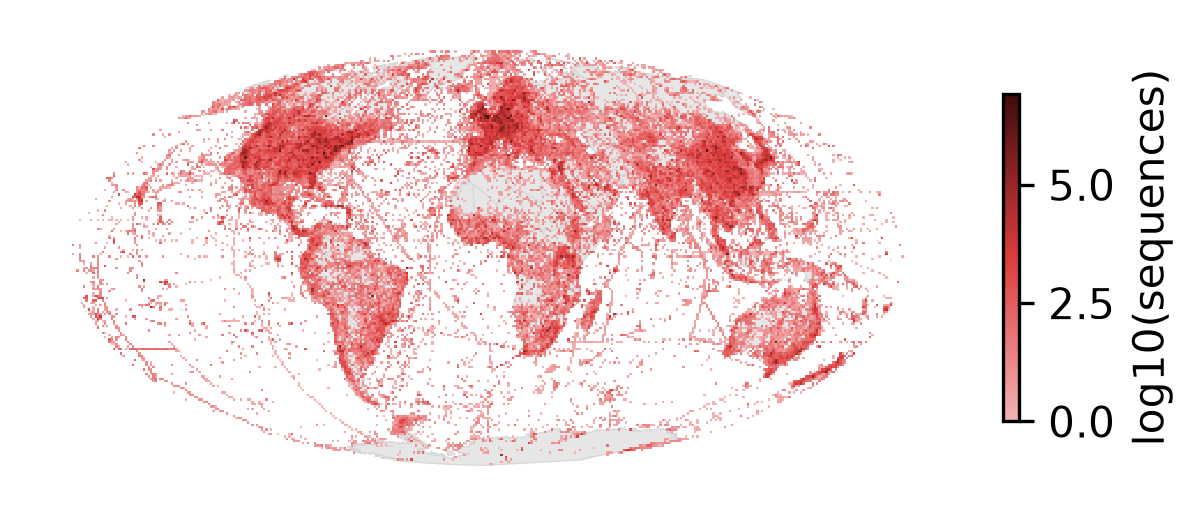

In [17]:
# ———— PLOT: WORLD MAP COLOURED BY CATALYTIC ORF SEQUENCE DENSITY ———— #
cm_to_in = 1 / 2.54
fig, ax = plt.subplots(figsize=(12.5 * cm_to_in, 6 * cm_to_in), dpi=300)

world.plot(ax=ax, facecolor="#e6e6e6", edgecolor="#d8d8d8", linewidth=0.3, zorder=1)

cmap = mcolors.LinearSegmentedColormap.from_list("density", ["#f2b3b4", "#dd3c3c", "#3f0b0b"])
plot_data = grid_sf_density.dropna(subset=["log10_sequence_count"])
plot_data.plot(
    ax=ax,
    column="log10_sequence_count",
    cmap=cmap,
    edgecolor="none",
    legend=True,
    legend_kwds={"label": "log10(sequences)", "shrink": 0.6},
    zorder=2,
)

ax.set_axis_off()
ax.set_facecolor("#f5f5f5")
fig.patch.set_alpha(0)

os.makedirs("outputs", exist_ok=True)
fig.savefig("outputs/logan_catalytic_orf_density_moll.png", dpi=300, transparent=True, bbox_inches="tight")
fig.savefig("outputs/logan_catalytic_orf_density_moll.svg", transparent=True, bbox_inches="tight")

plt.show()

In [19]:
grid_sf_density

,id,geometry,sequence_count,log10_sequence_count
0,1,"POLYGON ((-1830056.481 -9018990.687, -1830056....",NaN,NaN
1,2,"POLYGON ((-1730056.481 -9018990.687, -1730056....",NaN,NaN
2,3,"POLYGON ((-1630056.481 -9018990.687, -1630056....",NaN,NaN
3,4,"POLYGON ((-1530056.481 -9018990.687, -1530056....",NaN,NaN
4,5,"POLYGON ((-1430056.481 -9018990.687, -1430056....",NaN,NaN
...,...,...,...,...
51088,51089,"POLYGON ((2069943.519 8881009.313, 2069943.519...",30.0,1.477121
51089,51090,"POLYGON ((2169943.519 8881009.313, 2169943.519...",49.0,1.690196
51090,51091,"POLYGON ((2269943.519 8881009.313, 2269943.519...",NaN,NaN
51091,51092,"POLYGON ((2369943.519 8881009.313, 2369943.519...",NaN,NaN


In [ ]:
grid_sf_density.rename(columns={"sequence_count": "logan_sequence_count"}, inplace=True)